In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from pinecone import Pinecone
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import numpy as np
from tqdm import tqdm

# --- 환경 변수 및 클라이언트 로드 ---
load_dotenv()
pinecone_api_key = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=pinecone_api_key)

# --- 임베딩 모델 로드 ---
model_name = 'BM-K/KoSimCSE-roberta-multitask'
model = SentenceTransformer(model_name)

# --- Pinecone 인덱스 및 원본 데이터 로드 ---
index_name = "rag-assignment"
pinecone_index = pc.Index(index_name)
df = pd.read_parquet('../data/corpus_chunks.parquet')

print("✅ 기본 환경 설정 완료!")
print(f"Embedding Model: {model_name}")

c:\Users\qwer8\anaconda3\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No sentence-transformers model found with name BM-K/KoSimCSE-roberta-multitask. Creating a new one with mean pooling.


✅ 기본 환경 설정 완료!
Embedding Model: BM-K/KoSimCSE-roberta-multitask


In [2]:
from tqdm import tqdm

# BM25 인덱싱을 위해 텍스트 청크 리스트를 준비합니다.
corpus = df['text'].tolist()

# 텍스트를 띄어쓰기 기준으로 토큰화합니다.
print("⏳ BM25 인덱싱을 위한 토큰화를 시작합니다...")
tokenized_corpus = [doc.split(" ") for doc in tqdm(corpus)]

# BM25 인덱스를 생성합니다.
print("\n⏳ BM25 인덱스를 생성합니다...")
bm25 = BM25Okapi(tokenized_corpus)

print("✅ BM25 인덱스 구축 완료!")

⏳ BM25 인덱싱을 위한 토큰화를 시작합니다...


100%|██████████| 52272/52272 [00:00<00:00, 163409.20it/s]



⏳ BM25 인덱스를 생성합니다...
✅ BM25 인덱스 구축 완료!


In [3]:
def normalize_scores(results):
    """검색 결과의 점수를 0과 1 사이로 정규화하는 함수"""
    scores = [res['score'] for res in results]
    min_score, max_score = min(scores), max(scores)
    
    # 모든 점수가 동일한 경우(max_score == min_score), 0으로 나누는 것을 방지
    if max_score == min_score:
        return [1.0 for _ in results] # 모든 점수를 1로 설정하거나, 다른 적절한 값으로 설정
        
    for res in results:
        res['normalized_score'] = (res['score'] - min_score) / (max_score - min_score)
    return results

print("✅ 유틸리티 함수 준비 완료!")

✅ 유틸리티 함수 준비 완료!


In [4]:
# 1. Dense Search
def dense_search(query, top_k=5):
    """
    벡터(Dense) 검색을 수행하는 더 안전하고 완전한 버전의 함수
    """
    # 1. 질문을 벡터로 변환하여 Pinecone에 쿼리
    query_vector = model.encode(query).tolist()
    query_results = pinecone_index.query(
        vector=query_vector,
        top_k=top_k,
        include_metadata=True
    )['matches']
    
    # 2. 결과를 새로운 딕셔너리 리스트로 재구성 (안전한 방식)
    final_results = []
    for res in query_results:
        # 기본 정보(id, score)와 메타데이터를 합침
        metadata = res.get('metadata', {})
        
        full_text = df[df['chunk_id'] == res['id']]['text'].iloc[0]
        
        new_res = {
            'id': res['id'],
            'score': res['score'],
            'text': full_text,  # text 필드 추가!
            **metadata       # title, source, url 등 나머지 메타데이터 추가
        }
        final_results.append(new_res)
        
    return final_results

# 2. BM25 Search
def bm25_search(query, top_k=5):
    tokenized_query = query.split(" ")
    doc_scores = bm25.get_scores(tokenized_query)
    top_n_indices = np.argsort(doc_scores)[::-1][:top_k]
    
    return [{'id': df.iloc[idx]['chunk_id'], 'score': doc_scores[idx], **df.iloc[idx].to_dict()} for idx in top_n_indices]

# 3. Hybrid Search (Weighted Sum)
def hybrid_weighted_search(query, top_k=100, alpha=0.5):
    dense_res = normalize_scores(dense_search(query, top_k=top_k))
    bm25_res = normalize_scores(bm25_search(query, top_k=top_k))
    
    # 각 문서(id)별로 점수를 합산하기 위한 딕셔너리
    hybrid_scores = {}
    
    # Dense 점수 추가
    for res in dense_res:
        hybrid_scores[res['id']] = {'weighted_score': res['normalized_score'] * alpha, **res}
        
    # BM25 점수 추가 (또는 합산)
    for res in bm25_res:
        if res['id'] in hybrid_scores:
            hybrid_scores[res['id']]['weighted_score'] += res['normalized_score'] * (1 - alpha)
        else:
            hybrid_scores[res['id']] = {'weighted_score': res['normalized_score'] * (1 - alpha), **res}
            
    sorted_results = sorted(hybrid_scores.values(), key=lambda x: x['weighted_score'], reverse=True)
    return sorted_results

# 4. Hybrid Search (RRF)
def hybrid_rrf_search(query, top_k=100, k=60):
    dense_res = dense_search(query, top_k=top_k)
    bm25_res = bm25_search(query, top_k=top_k)
    
    rrf_scores = {}
    # Dense 순위 점수
    for rank, res in enumerate(dense_res):
        if res['id'] not in rrf_scores: rrf_scores[res['id']] = {'rrf_score': 0, **res}
        rrf_scores[res['id']]['rrf_score'] += 1 / (k + rank + 1)
        
    # BM25 순위 점수
    for rank, res in enumerate(bm25_res):
        if res['id'] not in rrf_scores: rrf_scores[res['id']] = {'rrf_score': 0, **res}
        rrf_scores[res['id']]['rrf_score'] += 1 / (k + rank + 1)
        
    sorted_results = sorted(rrf_scores.values(), key=lambda x: x['rrf_score'], reverse=True)
    return sorted_results

print("✅ 4가지 핵심 검색 함수 준비 완료!")

✅ 4가지 핵심 검색 함수 준비 완료!


In [5]:
from sentence_transformers.cross_encoder import CrossEncoder

# 공개된 고성능 Re-ranker 모델 사용
reranker_model = CrossEncoder('BAAI/bge-reranker-v2-m3')

def rerank(query, candidate_ids, top_k=10, batch_size=8):
    """
    Cross-Encoder를 사용하여 검색된 문서들의 순위를 재조정합니다.
    이 함수는 ID 리스트를 입력받아 내부에서 텍스트를 조회합니다.
    """
    
    # 1. 후보 ID를 기반으로 원본 텍스트를 가져옵니다.
    candidate_docs = df[df['chunk_id'].isin(candidate_ids)]
    id_to_text_map = dict(zip(candidate_docs['chunk_id'], candidate_docs['text']))
    
    # Hybrid Search 결과 순서를 유지하며 텍스트와 ID를 매핑합니다.
    passages = [id_to_text_map[doc_id] for doc_id in candidate_ids if doc_id in id_to_text_map]
    valid_ids = [doc_id for doc_id in candidate_ids if doc_id in id_to_text_map]

    if not valid_ids:
        return []

    # 2. Re-ranker 입력 형식([query, passage]) 생성
    sentence_pairs = [[query, passage] for passage in passages]
    all_scores = []
    
    # 3. 배치 처리로 메모리 오류 해결
    for i in range(0, len(sentence_pairs), batch_size):
        batch = sentence_pairs[i:i+batch_size]
        scores = reranker_model.predict(batch, show_progress_bar=False)
        if not isinstance(scores, list) and scores.ndim > 0:
            scores = scores.tolist()
        elif not isinstance(scores, list):
            scores = [scores] # 단일 값일 경우
        all_scores.extend(scores)

    # 4. 점수를 기준으로 내림차순 정렬
    sorted_pairs = sorted(zip(all_scores, valid_ids), key=lambda x: x[0], reverse=True)
    
    # 5. 최종 Top-k 결과 생성 (평가 파이프라인과 호환되는 형식)
    rerank_results = [{'id': doc_id, 'score': score} for score, doc_id in sorted_pairs[:top_k]]
        
    return rerank_results

print("✅ Re-ranker 준비 완료!")

✅ Re-ranker 준비 완료!


In [8]:
query = "밀양 송전탑 사건의 원인은 무엇인가?"
print(f"❓ 질문: {query}\n" + "="*50)

# 시나리오 1: Dense-Only
print("\n--- [1. Dense-Only 결과] ---")
results = dense_search(query, top_k=3)
for res in results:
    # text 키가 있는지 확인하여 안전하게 출력
    text_snippet = res.get('text', df.loc[df['chunk_id'] == res['id'], 'text'].iloc[0])
    print(f"  (Score: {res['score']:.4f}) {text_snippet[:80]}...")

# 시나리오 2: BM25-Only
print("\n--- [2. BM25-Only 결과] ---")
results = bm25_search(query, top_k=3)
for res in results:
    text_snippet = res.get('text', df.loc[df['chunk_id'] == res['id'], 'text'].iloc[0])
    print(f"  (Score: {res['score']:.4f}) {text_snippet[:80]}...")

# 시나리오 3: Hybrid (RRF)
print("\n--- [3. Hybrid (RRF) 결과] ---")
candidates_rrf = hybrid_rrf_search(query, top_k=3)
for res in candidates_rrf:
    text_snippet = res.get('text', df.loc[df['chunk_id'] == res['id'], 'text'].iloc[0])
    print(f"  (Score: {res.get('rrf_score', res.get('score', 0)):.6f}) {text_snippet[:80]}...")

# 시나리오 4: Hybrid + Re-rank (최종)
print("\n--- [4. Hybrid (RRF) + Re-rank 최종 결과] ---")

# 1. RRF 방식으로 후보군 확보 (평가 파이프라인과 동일하게)
candidates_for_rerank_res = hybrid_rrf_search(query, top_k=30)
candidate_ids = [res['id'] for res in candidates_for_rerank_res]

# 2. 후보군의 ID 리스트를 rerank 함수에 전달
final_results = rerank(query, candidate_ids, top_k=3)

# 3. rerank 결과를 바탕으로 원본 텍스트를 찾아 함께 출력
for res in final_results:
    # res는 {'id': ..., 'score': ...} 형식이므로, id를 사용해 df_corpus에서 text를 찾습니다.
    text_snippet = df.loc[df['chunk_id'] == res['id'], 'text'].iloc[0]
    print(f"  (Re-rank Score: {res['score']:.4f}) {text_snippet[:80]}...")

❓ 질문: 밀양 송전탑 사건의 원인은 무엇인가?

--- [1. Dense-Only 결과] ---
  (Score: 0.6453) 밀양 송전탑 사건(密陽送電塔事件)은 대한민국 경상남도 밀양시에 건설될 예정인 765 킬로볼트(kV)의 고압 송전선 및 송전탑의 위치 문제를 두고...
  (Score: 0.6453) 밀양 송전탑 사건(密陽送電塔事件)은 대한민국 경상남도 밀양시에 건설될 예정인 765 킬로볼트(kV)의 고압 송전선 및 송전탑의 위치 문제를 두고...
  (Score: 0.6254) 2.2 송전탑의 필요성과 원자력 발전소의 안전성에 관련된 논란...

--- [2. BM25-Only 결과] ---
  (Score: 22.8789) 밀양 765㎸ 송전탑 반대대책위원회
한국전력공사주요 인물...
  (Score: 22.8789) 밀양 765㎸ 송전탑 반대대책위원회
한국전력공사주요 인물...
  (Score: 21.1568) 밀양 송전탑 사건 - 위키백과, 우리 모두의 백과사전...

--- [3. Hybrid (RRF) 결과] ---
  (Score: 0.016393) 밀양 송전탑 사건(密陽送電塔事件)은 대한민국 경상남도 밀양시에 건설될 예정인 765 킬로볼트(kV)의 고압 송전선 및 송전탑의 위치 문제를 두고...
  (Score: 0.016393) 밀양 765㎸ 송전탑 반대대책위원회
한국전력공사주요 인물...
  (Score: 0.016129) 밀양 송전탑 사건(密陽送電塔事件)은 대한민국 경상남도 밀양시에 건설될 예정인 765 킬로볼트(kV)의 고압 송전선 및 송전탑의 위치 문제를 두고...
  (Score: 0.016129) 밀양 765㎸ 송전탑 반대대책위원회
한국전력공사주요 인물...
  (Score: 0.015873) 2.2 송전탑의 필요성과 원자력 발전소의 안전성에 관련된 논란...
  (Score: 0.015873) 밀양 송전탑 사건 - 위키백과, 우리 모두의 백과사전...

--- [4. Hybrid (RRF) + Re-rank 최종 결과] 

In [ ]:
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_colwidth', 300)

# target_title = '가짜뉴스'
# document_chunks = df[df['title'] == target_title]

# # 해당 문서의 chunk_id와 text 내용을 출력
# print(f"--- [문서 제목: {target_title}] ---")
# for index, row in document_chunks.iterrows():
#     print(f"Chunk ID: {row['chunk_id']}")
#     print(f"Text: {row['text'][:2000]}...") # 내용의 일부만 출력
#     print("-" * 20)

In [9]:
eval_queries = [
    {
        "query": "신고리~북경남 765kV 송전선은 어디서 생산한 전력을 어디로 수송하도록 계획되었나?",
        "ground_truth_id": "doc_0-chunk_29"
    },
    {
        "query": "2013년 9월 11일 확정된 밀양 송전탑 갈등 보상안의 핵심 내용은 무엇이었나?",
        "ground_truth_id": "doc_0-chunk_36"
    },
    {
        "query": "서울의대(정부 과제) 역학조사가 ‘전자계와 소아암’ 관련해 내린 결론은 무엇이었나?",
        "ground_truth_id": "doc_0-chunk_37"
    },
    {
        "query": "2018 자카르타-팔렘방 아시안게임에서 e스포츠가 공식 메달 집계에 반영되지 않은 이유와 정식 종목 편입 시점은?",
        "ground_truth_id": "doc_2-chunk_29"
    },
    {
        "query": "2018년 아시안게임 e스포츠 시범종목으로 채택된 여섯 개 게임은 무엇이었나?",
        "ground_truth_id": "doc_2-chunk_29"
    },
    {
        "query": "아시안게임 e스포츠 예선은 언제 어떤 지역 구분으로 치러졌고, 개최국 인도네시아의 본선 진출 방식과 ‘펜타스톰’ 예외 규정은?",
        "ground_truth_id": "doc_2-chunk_75"
    },
    {
        "query": "‘플라스틱’이라는 단어의 어원과, 열가소성수지와 열경화성수지의 구분 기준은?",
        "ground_truth_id": "doc_171-chunk_16"
    },
    {
        "query": "인간이 만든 최초의 플라스틱은 무엇이며, 누가 언제 특허를 받았는가?",
        "ground_truth_id": "doc_171-chunk_19"
    },
    {
        "query": "플라스틱 재활용 과정에서 품질이 저하되는 이유와 Jianbo Zhu 박사의 연구 성과는 무엇인가?",
        "ground_truth_id": "doc_171-chunk_20"
    },
    {
        "query": "《루팡 3세 VS 명탐정 코난》은 어떤 방송국들의 개국 기념 프로그램이며, 한국에서는 언제 어디서 방영됐나?",
        "ground_truth_id": "doc_98-chunk_39"
    },
    {
        "query": "베스파니아 왕국에서 사쿠라 여왕과 질 왕자의 사망 이후 밀러 공주, 루팡, 코난이 각각 어떤 행동을 펼치나?",
        "ground_truth_id": "doc_98-chunk_49"
    },
    {
        "query": "이 스페셜의 DVD/Blu-ray 발매 정보와 일본 내 판매·랭킹 성과는 어떻게 기록돼 있나?",
        "ground_truth_id": "doc_98-chunk_53"
    },
    {
        "query": "리쌍은 어떤 구성의 힙합 듀오이며 언제부터 언제까지 활동했고, 해체는 어떻게 진행됐나?",
        "ground_truth_id": "doc_245-chunk_33"
    },
    {
        "query": "정규 7집 《AsuRa BalBalTa》의 타이틀곡 중 어떤 곡들이 심의에서 방송 금지 판정을 받았고, 앨범의 음원 성적은 어땠나?",
        "ground_truth_id": "doc_245-chunk_44"
    },
    {
        "query": "리쌍의 정규 음반 전체 목록과 발매일을 순서대로 알려줘.",
        "ground_truth_id": "doc_245-chunk_54"
    },
    {
        "query": "‘기기괴괴’는 어떤 웹툰이며, 연재 플랫폼과 장르는 무엇인가?",
        "ground_truth_id": "doc_60-chunk_33"
    },
    {
        "query": "본편 ‘성형수’ 편의 연재 기간과 총 회차는?",
        "ground_truth_id": "doc_60-chunk_60"
    },
    {
        "query": "‘장르파괴괴’의 각 연재일은 언제였나?",
        "ground_truth_id": "doc_60-chunk_74"
    },
    {
        "query": "장원영은 언제 어디에서 태어났으며, 어떤 가족 배경을 가지고 있나?",
        "ground_truth_id": "doc_55-chunk_31"
    },
    {
        "query": "장원영이 스타쉽 엔터테인먼트 연습생이 된 계기와 이후 ‘프로듀스 48’에서의 성과는?",
        "ground_truth_id": "doc_55-chunk_31"
    },
    # {
    #     "query": "장원영의 학력과 검정고시 응시 배경을 알려줘.",
    #     "ground_truth_id": "doc_55-chunk_32"
    # },
    # {
    #     "query": "영화 《카사블랑카》의 배경과 실제 촬영지는 어디이며, 왜 현지 촬영이 이루어지지 않았나?",
    #     "ground_truth_id": "doc_92-chunk_49"
    # },
    # {
    #     "query": "영화 결말에서 릭이 공항에서 내린 선택은 무엇이며, 그 선택이 의미하는 바는?",
    #     "ground_truth_id": "doc_92-chunk_59"
    # },
    # {
    #     "query": "《카사블랑카》가 아카데미 시상식에서 수상한 부문들은 무엇인가?",
    #     "ground_truth_id": "doc_92-chunk_49"
    # },
    # {
    #     "query": "이종석의 브라운관 데뷔작은 무엇이며, 같은 해 대중에게 이름을 알린 작품은 무엇인가?",
    #     "ground_truth_id": "doc_82-chunk_30"
    # },
    # {
    #     "query": "이종석의 출생일과 출생지는 어디인가?",
    #     "ground_truth_id": "doc_82-chunk_17"
    # },
    # {
    #     "query": "이종석이 2016년 MBC 연기대상에서 받은 상들은 무엇인가?",
    #     "ground_truth_id": "doc_82-chunk_30"
    # },
    # {
    #     "query": "Claire Wardle가 제시한 가짜뉴스의 일곱 가지 유형은 무엇인가?",
    #     "ground_truth_id": "doc_407-chunk_20"
    # },
    # {
    #     "query": "IFLA가 제안한 가짜뉴스 식별 체크리스트 항목들을 모두 나열하라.",
    #     "ground_truth_id": "doc_407-chunk_22"
    # },
    # {
    #     "query": "2018년 연구에 따르면 가짜뉴스의 전파 양상과 봇의 역할은 어떻게 설명되는가?",
    #     "ground_truth_id": "doc_407-chunk_25"
    # },
]

print(f"✅ 총 {len(eval_queries)}개의 평가용 질문이 준비되었습니다.")

✅ 총 20개의 평가용 질문이 준비되었습니다.


In [10]:
def calculate_recall_at_k(retrieved_ids, ground_truth_id, k):
    """상위 K개 결과에 정답이 포함되었는지 (1 또는 0) 계산합니다."""
    return 1 if ground_truth_id in retrieved_ids[:k] else 0

def calculate_mrr_at_k(retrieved_ids, ground_truth_id, k):
    """정답의 순위 역수를 계산합니다. 없으면 0을 반환합니다."""
    for i, doc_id in enumerate(retrieved_ids[:k]):
        if doc_id == ground_truth_id:
            return 1 / (i + 1)
    return 0

def calculate_ndcg_at_k(retrieved_ids, ground_truth_id, k):
    """NDCG@k를 계산합니다."""
    for i, doc_id in enumerate(retrieved_ids[:k]):
        if doc_id == ground_truth_id:
            # DCG = 1 / log2(rank + 1), IDCG = 1 (정답이 하나이므로)
            return 1 / np.log2(i + 2)
    return 0

print("✅ 평가 지표 계산 함수 준비 완료!")

✅ 평가 지표 계산 함수 준비 완료!


In [11]:
import time

K = 10 # 평가는 Top-10을 기준으로 진행
evaluation_results = []
total_queries = len(eval_queries)

print("="*50)
print("🚀 평가 파이프라인을 시작합니다...")
print(f"총 {total_queries}개의 쿼리에 대해 평가를 진행합니다.")
print("="*50)


for i, item in enumerate(eval_queries):
    query = item['query']
    gt_id = item['ground_truth_id']
    
    print(f"\n--- [쿼리 {i+1}/{total_queries} 평가 시작] ---")
    print(f"Query: {query[:50]}...")
    
    query_times = {}

    # 1. Dense Search
    start_time = time.time()
    dense_res = dense_search(query, top_k=K)
    query_times['dense_latency'] = time.time() - start_time
    print(f"  - (1/4) Dense Search 완료 ({query_times['dense_latency']:.2f}초)")

    # 2. BM25 Search
    start_time = time.time()
    bm25_res = bm25_search(query, top_k=K)
    query_times['bm25_latency'] = time.time() - start_time
    print(f"  - (2/4) BM25 Search 완료 ({query_times['bm25_latency']:.2f}초)")

    # 3. Hybrid Search (RRF) - 내부 단계 측정
    hybrid_start_time = time.time()
    # 후보군 확보 (Dense)
    dense_candidates_for_hybrid = dense_search(query, top_k=100)
    t1 = time.time()
    # 후보군 확보 (BM25)
    bm25_candidates_for_hybrid = bm25_search(query, top_k=100)
    t2 = time.time()
    # RRF 계산
    # (실제 RRF 계산 로직은 매우 빠르므로, 후보군 확보가 시간의 대부분을 차지합니다)
    hybrid_res = hybrid_rrf_search(query, top_k=K) # 함수 재호출 (캐싱이 안되므로 시간 측정용)
    t3 = time.time()
    query_times['hybrid_latency'] = t3 - hybrid_start_time
    print(f"  - (3/4) Hybrid Search 완료 ({query_times['hybrid_latency']:.2f}초) "
          f"[내부: Dense({t1-hybrid_start_time:.2f}s) + BM25({t2-t1:.2f}s) + RRF({t3-t2:.2f}s)]")

    # 4. Hybrid + Re-rank - 내부 단계 측정
    rerank_start_time = time.time()
    # 후보군 확보 (Hybrid)
    candidates_for_rerank_res = hybrid_rrf_search(query, top_k=30) 
    # 후보군의 'id'만 리스트로 추출해서 전달
    candidates_ids_for_rerank = [res['id'] for res in candidates_for_rerank_res]
    t4 = time.time()
    # Re-ranker 점수 계산
    rerank_res = rerank(query, candidates_ids_for_rerank, top_k=K)
    t5 = time.time()
    query_times['rerank_latency'] = t5 - rerank_start_time
    print(f"  - (4/4) Re-rank Search 완료 ({query_times['rerank_latency']:.2f}초) "
          f"[내부: 후보군 확보({t4-rerank_start_time:.2f}s) + Re-ranking({t5-t4:.2f}s)]")

    # 결과 ID 리스트 추출
    dense_ids = [res['id'] for res in dense_res]
    bm25_ids = [res['id'] for res in bm25_res]
    hybrid_ids = [res['id'] for res in hybrid_res]
    rerank_ids = [res['id'] for res in rerank_res]

    # 각 방식별로 지표 계산
    evaluation_results.append({
        'query': query,
        'dense_recall': calculate_recall_at_k(dense_ids, gt_id, K),
        'dense_mrr': calculate_mrr_at_k(dense_ids, gt_id, K),
        'dense_ndcg': calculate_ndcg_at_k(dense_ids, gt_id, K),
        'dense_latency': query_times['dense_latency'],
        'bm25_recall': calculate_recall_at_k(bm25_ids, gt_id, K),
        'bm25_mrr': calculate_mrr_at_k(bm25_ids, gt_id, K),
        'bm25_ndcg': calculate_ndcg_at_k(bm25_ids, gt_id, K),
        'bm25_latency': query_times['bm25_latency'],
        'hybrid_recall': calculate_recall_at_k(hybrid_ids, gt_id, K),
        'hybrid_mrr': calculate_mrr_at_k(hybrid_ids, gt_id, K),
        'hybrid_ndcg': calculate_ndcg_at_k(hybrid_ids, gt_id, K),
        'hybrid_latency': query_times['hybrid_latency'],
        'rerank_recall': calculate_recall_at_k(rerank_ids, gt_id, K),
        'rerank_mrr': calculate_mrr_at_k(rerank_ids, gt_id, K),
        'rerank_ndcg': calculate_ndcg_at_k(rerank_ids, gt_id, K),
        'rerank_latency': query_times['rerank_latency'],
    })

# 최종 결과를 DataFrame으로 변환
eval_df = pd.DataFrame(evaluation_results)
print("\n" + "="*50)
print("🎉 모든 평가가 완료되었습니다!")
print("="*50)
eval_df.head()

🚀 평가 파이프라인을 시작합니다...
총 20개의 쿼리에 대해 평가를 진행합니다.

--- [쿼리 1/20 평가 시작] ---
Query: 신고리~북경남 765kV 송전선은 어디서 생산한 전력을 어디로 수송하도록 계획되었나?...
  - (1/4) Dense Search 완료 (2.40초)
  - (2/4) BM25 Search 완료 (0.22초)
  - (3/4) Hybrid Search 완료 (1.26초) [내부: Dense(0.80s) + BM25(0.08s) + RRF(0.37s)]
  - (4/4) Re-rank Search 완료 (42.18초) [내부: 후보군 확보(0.47s) + Re-ranking(41.70s)]

--- [쿼리 2/20 평가 시작] ---
Query: 2013년 9월 11일 확정된 밀양 송전탑 갈등 보상안의 핵심 내용은 무엇이었나?...
  - (1/4) Dense Search 완료 (0.30초)
  - (2/4) BM25 Search 완료 (0.40초)
  - (3/4) Hybrid Search 완료 (1.01초) [내부: Dense(0.54s) + BM25(0.11s) + RRF(0.37s)]
  - (4/4) Re-rank Search 완료 (47.96초) [내부: 후보군 확보(0.42s) + Re-ranking(47.54s)]

--- [쿼리 3/20 평가 시작] ---
Query: 서울의대(정부 과제) 역학조사가 ‘전자계와 소아암’ 관련해 내린 결론은 무엇이었나?...
  - (1/4) Dense Search 완료 (0.31초)
  - (2/4) BM25 Search 완료 (0.12초)
  - (3/4) Hybrid Search 완료 (0.98초) [내부: Dense(0.55s) + BM25(0.08s) + RRF(0.35s)]
  - (4/4) Re-rank Search 완료 (97.69초) [내부: 후보군 확보(0.49s) + Re-ranking(97.20s)]

--- [쿼리 4/20 평가 시작] ---
Query

,query,dense_recall,dense_mrr,dense_ndcg,dense_latency,bm25_recall,bm25_mrr,bm25_ndcg,bm25_latency,hybrid_recall,hybrid_mrr,hybrid_ndcg,hybrid_latency,rerank_recall,rerank_mrr,rerank_ndcg,rerank_latency
0,신고리~북경남 765kV 송전선은 어디서 생산한 전력을 어디로 수송하도록 계획되었나?,1,0.5,0.63093,2.399451,1,0.500000,0.630930,0.219545,1,1.0,1.00000,1.256260,1,0.5,0.63093,42.178124
1,2013년 9월 11일 확정된 밀양 송전탑 갈등 보상안의 핵심 내용은 무엇이었나?,1,1.0,1.00000,0.300934,1,0.166667,0.356207,0.401160,1,1.0,1.00000,1.011179,1,0.5,0.63093,47.960435
2,서울의대(정부 과제) 역학조사가 ‘전자계와 소아암’ 관련해 내린 결론은 무엇이었나?,1,1.0,1.00000,0.306767,0,0.000000,0.000000,0.116510,1,1.0,1.00000,0.983403,1,1.0,1.00000,97.685933
3,2018 자카르타-팔렘방 아시안게임에서 e스포츠가 공식 메달 집계에 반영되지 않은 ...,1,0.5,0.63093,1.199422,1,0.500000,0.630930,0.219829,1,0.5,0.63093,1.397242,1,0.5,0.63093,56.351582
4,2018년 아시안게임 e스포츠 시범종목으로 채택된 여섯 개 게임은 무엇이었나?,1,1.0,1.00000,0.365532,1,0.250000,0.430677,0.284175,1,1.0,1.00000,1.214899,1,1.0,1.00000,43.723167


--- [최종 성능 요약] ---
           Method  Recall@10    MRR@10   NDCG@10  Avg Latency (s)
0           Dense        0.8  0.514583  0.586599         1.237488
1            BM25        0.5  0.294643  0.344104         0.279284
2    Hybrid (RRF)        0.8  0.593333  0.645529         1.297947
3  Hybrid+Re-rank        0.8  0.700000  0.726186       123.312759

💾 최종 성능 지표가 '../results/metrics.csv'에 저장되었습니다.
📊 성능 비교 그래프가 '../results/performance_comparison.png'에 저장되었습니다.


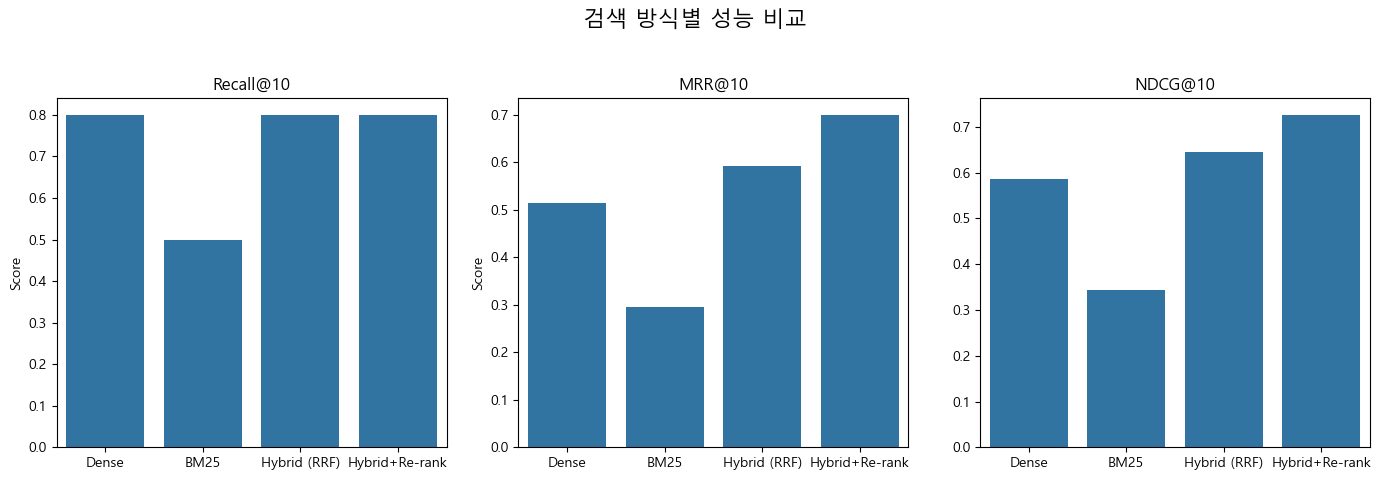

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지


# 평균 성능 계산
summary = {
    'Method': ['Dense', 'BM25', 'Hybrid (RRF)', 'Hybrid+Re-rank'],
    f'Recall@{K}': [
        eval_df['dense_recall'].mean(),
        eval_df['bm25_recall'].mean(),
        eval_df['hybrid_recall'].mean(),
        eval_df['rerank_recall'].mean()
    ],
    f'MRR@{K}': [
        eval_df['dense_mrr'].mean(),
        eval_df['bm25_mrr'].mean(),
        eval_df['hybrid_mrr'].mean(),
        eval_df['rerank_mrr'].mean()
    ],
    f'NDCG@{K}': [
        eval_df['dense_ndcg'].mean(),
        eval_df['bm25_ndcg'].mean(),
        eval_df['hybrid_ndcg'].mean(),
        eval_df['rerank_ndcg'].mean()
    ],
    'Avg Latency (s)': [
        eval_df['dense_latency'].mean(),
        eval_df['bm25_latency'].mean(),
        eval_df['hybrid_latency'].mean(),
        eval_df['rerank_latency'].mean()
    ]
}
summary_df = pd.DataFrame(summary)

print("--- [최종 성능 요약] ---")
print(summary_df)


# --- 결과 저장 ---
output_dir = '../results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. 지표 CSV 파일로 저장
summary_df.to_csv(f'{output_dir}/metrics.csv', index=False)
print(f"\n💾 최종 성능 지표가 '{output_dir}/metrics.csv'에 저장되었습니다.")

# 2. 그래프 생성 및 이미지 파일로 저장
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('검색 방식별 성능 비교', fontsize=16)

sns.barplot(x='Method', y=f'Recall@{K}', data=summary_df, ax=axes[0])
axes[0].set_title(f'Recall@{K}')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('')

sns.barplot(x='Method', y=f'MRR@{K}', data=summary_df, ax=axes[1])
axes[1].set_title(f'MRR@{K}')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('')

sns.barplot(x='Method', y=f'NDCG@{K}', data=summary_df, ax=axes[2])
axes[2].set_title(f'NDCG@{K}')
axes[2].set_ylabel('')
axes[2].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plot_path = f'{output_dir}/performance_comparison.png'
plt.savefig(plot_path)
print(f"📊 성능 비교 그래프가 '{plot_path}'에 저장되었습니다.")
plt.show()

In [14]:
# 사례 1: BM25는 성공했지만 Dense는 실패한 경우 (키워드가 매우 중요했던 쿼리)
print("--- [사례 1 후보: BM25 성공 / Dense 실패] ---")
print(eval_df[(eval_df['bm25_recall'] == 1) & (eval_df['dense_recall'] == 0)][['query', 'bm25_mrr', 'dense_mrr']])

# 사례 2: Dense는 성공했지만 BM25는 실패한 경우 (의미가 매우 중요했던 쿼리)
print("\n--- [사례 2 후보: Dense 성공 / BM25 실패] ---")
print(eval_df[(eval_df['dense_recall'] == 1) & (eval_df['bm25_recall'] == 0)][['query', 'dense_mrr', 'bm25_mrr']])

# 사례 3: Re-ranker가 순위를 극적으로 끌어올린 경우
print("\n--- [사례 3 후보: Re-ranker의 역전] ---")
# Hybrid보다 Re-rank의 MRR이 0.5 이상 상승한 경우
print(eval_df[eval_df['rerank_mrr'] - eval_df['hybrid_mrr'] > 0.5][['query', 'hybrid_mrr', 'rerank_mrr']])

# 사례 4: 모든 검색 방식이 실패한 어려운 쿼리
print("\n--- [사례 4 후보: 모두 실패] ---")
print(eval_df[eval_df['rerank_recall'] == 0][['query']])

--- [사례 1 후보: BM25 성공 / Dense 실패] ---
Empty DataFrame
Columns: [query, bm25_mrr, dense_mrr]
Index: []

--- [사례 2 후보: Dense 성공 / BM25 실패] ---
                                                query  dense_mrr  bm25_mrr
2      서울의대(정부 과제) 역학조사가 ‘전자계와 소아암’ 관련해 내린 결론은 무엇이었나?   1.000000       0.0
6          ‘플라스틱’이라는 단어의 어원과, 열가소성수지와 열경화성수지의 구분 기준은?   1.000000       0.0
8   플라스틱 재활용 과정에서 품질이 저하되는 이유와 Jianbo Zhu 박사의 연구 성...   1.000000       0.0
12   리쌍은 어떤 구성의 힙합 듀오이며 언제부터 언제까지 활동했고, 해체는 어떻게 진행됐나?   0.333333       0.0
15                 ‘기기괴괴’는 어떤 웹툰이며, 연재 플랫폼과 장르는 무엇인가?   0.333333       0.0
17                              ‘장르파괴괴’의 각 연재일은 언제였나?   0.500000       0.0

--- [사례 3 후보: Re-ranker의 역전] ---
                                 query  hybrid_mrr  rerank_mrr
15  ‘기기괴괴’는 어떤 웹툰이며, 연재 플랫폼과 장르는 무엇인가?    0.200000         1.0
17               ‘장르파괴괴’의 각 연재일은 언제였나?    0.333333         1.0

--- [사례 4 후보: 모두 실패] ---
                                                query
11  이 스페셜의 DVD/Blu-ray 발매 정보와 일

In [17]:
def analyze_query_results(query_index):
    """
    특정 쿼리에 대한 각 검색 방식의 결과를 상세히 출력하여 정성적 분석을 돕는 함수.
    """
    if not (0 <= query_index < len(eval_queries)):
        print(f"❌ 잘못된 인덱스입니다. 0과 {len(eval_queries)-1} 사이의 값을 입력해주세요.")
        return

    # 1. 분석할 쿼리와 정답 정보 가져오기
    item = eval_queries[query_index]
    query = item['query']
    gt_id = item['ground_truth_id']
    gt_text = df[df['chunk_id'] == gt_id]['text'].iloc[0]

    print("=" * 80)
    print(f"🔍 [쿼리 #{query_index} 분석 시작]")
    print(f"❓ 쿼리: {query}")
    print("-" * 80)
    print(f"✅ 정답 (ID: {gt_id})")
    print(f"   >> {gt_text[:150]}...")
    print("=" * 80)

    # 2. 분석할 검색 함수 리스트
    # Re-ranker는 입력 방식이 다르므로 별도 처리
    search_methods = {
        "Dense": dense_search,
        "BM25": bm25_search,
        "Hybrid (RRF)": hybrid_rrf_search,
    }

    # 3. 각 방식별 결과 출력
    for name, search_func in search_methods.items():
        print(f"\n--- [결과: {name}] ---")
        results = search_func(query, top_k=5)
        if not results:
            print("  -> 결과 없음")
            continue
        for i, res in enumerate(results):
            res_id = res['id']
            res_text = df[df['chunk_id'] == res_id]['text'].iloc[0]
            marker = "⭐ 정답!" if res_id == gt_id else ""
            print(f"  {i+1}. (ID: {res_id}) {res_text[:100]}... {marker}")

    # 4. Re-ranker 결과 별도 처리
    print("\n--- [결과: Hybrid + Re-rank] ---")
    # 후보군 확보
    candidate_res = hybrid_rrf_search(query, top_k=30)
    candidate_ids = [res['id'] for res in candidate_res]
    # 재순위화
    reranked_results = rerank(query, candidate_ids, top_k=5)
    if not reranked_results:
        print("  -> 결과 없음")
    else:
        for i, res in enumerate(reranked_results):
            res_id = res['id']
            res_text = df[df['chunk_id'] == res_id]['text'].iloc[0]
            marker = "⭐ 정답!" if res_id == gt_id else ""
            print(f"  {i+1}. (ID: {res_id}) {res_text[:100]}... {marker}")

    print("\n" + "=" * 80)
    print("✅ 분석 완료")
    print("=" * 80)


ANALYZE_INDEX = 11
analyze_query_results(ANALYZE_INDEX)

🔍 [쿼리 #11 분석 시작]
❓ 쿼리: 이 스페셜의 DVD/Blu-ray 발매 정보와 일본 내 판매·랭킹 성과는 어떻게 기록돼 있나?
--------------------------------------------------------------------------------
✅ 정답 (ID: doc_98-chunk_53)
   >> 오기타 소지 - TV판 제 2 시리즈 제 71화《루팡 대 신선조》의 등장인물로 오기타 소지의 손자되는 인물. 《명탐정 코난》과 《야이바》에서도 게스트로 같은 이름의 캐릭터가 등장한다. 하지만 《코난》 및 《야이바》에 등장하는 오기타 소지는 선대 오기타 소지의 6대 후손...

--- [결과: Dense] ---
  1. (ID: doc_98-chunk_56) ↑ “Japanese Animation DVD Ranking, July 20-26”. 아니메 뉴스 네트워크. 2009년 7월 29일. 2009년 11월 14일에 확인함.... 
  2. (ID: doc_99-chunk_56) ↑ “Japanese Animation DVD Ranking, July 20-26”. 아니메 뉴스 네트워크. 2009년 7월 29일. 2009년 11월 14일에 확인함.... 
  3. (ID: doc_144-chunk_54) BANDAI (반다이)
EMOTION DIGITAL SOFTWARE(이모션 디지털 소프트웨어, 주로 게임 소프트)
BANDAI HOME VIDEO(반다이 홈 비디오)
BANDAI ... 
  4. (ID: doc_143-chunk_54) BANDAI (반다이)
EMOTION DIGITAL SOFTWARE(이모션 디지털 소프트웨어, 주로 게임 소프트)
BANDAI HOME VIDEO(반다이 홈 비디오)
BANDAI ... 
  5. (ID: doc_556-chunk_99) 싱글 목록
음반 목록
음반 외 활동 목록
콘서트 투어 목록
경력·수상 목록
  분류
  위키공용... 

--- [결과: BM25] ---
  1. (ID: d